# 03 — RFM segmentation

Scores every customer on **R**ecency, **F**requency and **M**onetary value, then groups them into segments
the sales team can act on.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd

from src.metrics import save_metrics
from src.style import BLUE, INK_2, ORANGE, apply_style, save

apply_style()
pd.set_option("display.width", 140)

df = pd.read_parquet(ROOT / "data" / "clean.parquet")
print(f"{len(df):,} rows, {df['Customer ID'].nunique():,} customers")

776,579 rows, 5,852 customers


## 1–2. Snapshot date and raw R, F, M

- **Snapshot** = last invoice timestamp + 1 day, so the most recent buyer has recency 1 rather than 0.
- **Recency** = whole days from a customer's last purchase to the snapshot.
- **Frequency** = distinct invoices. Line items would reward customers who put many products on one order.
- **Monetary** = total revenue in £ (cancellations excluded, as cleaned in notebook 01).

In [2]:
snapshot = df["InvoiceDate"].max() + pd.Timedelta(days=1)
print("snapshot date:", snapshot)

rfm = df.groupby("Customer ID").agg(
    last_purchase=("InvoiceDate", "max"),
    frequency=("Invoice", "nunique"),
    monetary=("Revenue", "sum"),
)
rfm["recency"] = (snapshot - rfm["last_purchase"]).dt.days
rfm = rfm[["recency", "frequency", "monetary"]]
rfm.describe().round(1)

snapshot date: 2011-12-10 12:50:00


,recency,frequency,monetary
count,5852.0,5852.0,5852.0
mean,200.2,6.3,2916.7
std,208.5,12.7,14306.9
min,1.0,1.0,3.0
25%,25.0,1.0,339.6
50%,95.0,3.0,856.0
75%,379.0,7.0,2241.0
max,739.0,373.0,580987.0


## 3. Scores 1–5

Quintiles via `pd.qcut`. Recency is reversed so that recent buyers score 5.
Half of all customers have 1–3 invoices, so frequency quintile edges would repeat and `qcut` would fail.
Ranking first (`method="first"`) breaks ties by row order, which gives five equal-sized bins.

In [3]:
rfm["R"] = pd.qcut(rfm["recency"], 5, labels=[5, 4, 3, 2, 1]).astype(int)
rfm["F"] = pd.qcut(rfm["frequency"].rank(method="first"), 5, labels=[1, 2, 3, 4, 5]).astype(int)
rfm["M"] = pd.qcut(rfm["monetary"], 5, labels=[1, 2, 3, 4, 5]).astype(int)

# Each score should split customers into ~equal fifths
pd.DataFrame({s: rfm[s].value_counts().sort_index() for s in ["R", "F", "M"]})

,R,F,M
1,1163,1171,1171
2,1173,1170,1170
3,1155,1170,1170
4,1174,1170,1170
5,1187,1171,1171


## 4. Segment rules

Rules are checked **in this order** and the first match wins, so overlapping rules (e.g. Champions vs Loyal) are unambiguous.

| Segment | Rule | Meaning |
|---|---|---|
| Champions | R≥4 and F≥4 | bought recently and often |
| Loyal | F≥4 and R≥3 | frequent buyers, slightly less recent |
| Potential | R≥4 and F≤3 | recent but not yet frequent: nurture |
| At-Risk | R≤2 and F≥3 | used to buy regularly, has gone quiet: win back |
| Hibernating | R≤2, F≤2, M≥3 | infrequent and quiet, but spent a fair amount |
| Lost | R≤2 (everyone else) | infrequent, quiet, low spend |
| Other | remaining | middle recency (R=3) and F≤3 |

No segment came out empty or absurd, so the rules are unchanged from the project brief.

In [4]:
conditions = [
    (rfm["R"] >= 4) & (rfm["F"] >= 4),
    (rfm["F"] >= 4) & (rfm["R"] >= 3),
    (rfm["R"] >= 4) & (rfm["F"] <= 3),
    (rfm["R"] <= 2) & (rfm["F"] >= 3),
    (rfm["R"] <= 2) & (rfm["F"] <= 2) & (rfm["M"] >= 3),
    (rfm["R"] <= 2),
]
names = ["Champions", "Loyal", "Potential", "At-Risk", "Hibernating", "Lost"]
# np.select takes the first condition that is true, matching the rule order above
rfm["segment"] = np.select(conditions, names, default="Other")
rfm["segment"].value_counts()

segment
Champions      1476
Lost           1269
Potential       885
At-Risk         828
Other           648
Loyal           507
Hibernating     239
Name: count, dtype: int64

## 5. Segment summary

In [5]:
SEGMENT_ORDER = ["Champions", "Loyal", "Potential", "At-Risk", "Hibernating", "Lost", "Other"]

segments = (
    rfm.groupby("segment")
    .agg(customers=("R", "size"), revenue=("monetary", "sum"),
         avg_recency=("recency", "mean"), avg_frequency=("frequency", "mean"))
    .reindex(SEGMENT_ORDER)
)
segments["pct_customers"] = 100 * segments["customers"] / segments["customers"].sum()
segments["pct_revenue"] = 100 * segments["revenue"] / segments["revenue"].sum()
segments = segments[["customers", "pct_customers", "revenue", "pct_revenue", "avg_recency", "avg_frequency"]]
segments = segments.reset_index().round({"pct_customers": 1, "revenue": 0, "pct_revenue": 1,
                                          "avg_recency": 0, "avg_frequency": 1})
assert segments["customers"].sum() == len(rfm)
segments

,segment,customers,pct_customers,revenue,pct_revenue,avg_recency,avg_frequency
0,Champions,1476,25.2,11816450.0,69.2,20.0,15.6
1,Loyal,507,8.7,1627960.0,9.5,106.0,8.4
2,Potential,885,15.1,873898.0,5.1,26.0,2.3
3,At-Risk,828,14.1,1592996.0,9.3,368.0,5.0
4,Hibernating,239,4.1,299837.0,1.8,416.0,1.6
5,Lost,1269,21.7,320422.0,1.9,465.0,1.2
6,Other,648,11.1,537019.0,3.1,109.0,2.1


## 6. Chart: share of customers vs share of revenue

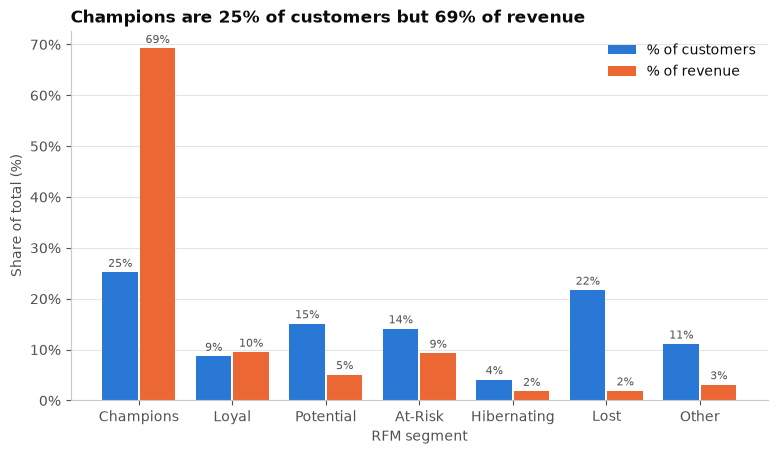

In [6]:
seg = segments.set_index("segment")
champ, at_risk = seg.loc["Champions"], seg.loc["At-Risk"]

x = np.arange(len(seg))
width = 0.38
fig, ax = plt.subplots(figsize=(9, 4.8))
bars_c = ax.bar(x - width / 2 - 0.01, seg["pct_customers"], width, color=BLUE, label="% of customers")
bars_r = ax.bar(x + width / 2 + 0.01, seg["pct_revenue"], width, color=ORANGE, label="% of revenue")
for bars in (bars_c, bars_r):
    ax.bar_label(bars, fmt="%.0f%%", padding=2, fontsize=8, color=INK_2)
ax.set_xticks(x, seg.index)
ax.set_title(f"Champions are {champ['pct_customers']:.0f}% of customers but {champ['pct_revenue']:.0f}% of revenue")
ax.set_ylabel("Share of total (%)")
ax.set_xlabel("RFM segment")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
ax.legend(loc="upper right")
save(fig, "03_rfm_segments.png")
plt.show()

**Reading the chart.** Revenue is concentrated in Champions. The actionable group is **At-Risk**: customers who used
to order regularly (F≥3) but have gone quiet (R≤2). They still represent meaningful historical revenue, and they are
the natural target for a win-back campaign.

## 7. Verify: recompute R, F, M for two random customers with plain pandas

This reads `clean.parquet` again and filters rows directly, with no groupby, as an independent check on the aggregation.

In [7]:
check = pd.read_parquet(ROOT / "data" / "clean.parquet")
rng = np.random.default_rng(42)
sample_ids = rng.choice(rfm.index.to_numpy(), size=2, replace=False)

for cid in sample_ids:
    rows = check[check["Customer ID"] == cid]
    recency = (check["InvoiceDate"].max() + pd.Timedelta(days=1) - rows["InvoiceDate"].max()).days
    frequency = len(set(rows["Invoice"]))
    monetary = float((rows["Quantity"] * rows["Price"]).sum())
    expected = rfm.loc[cid]
    print(f"customer {cid}: R={recency} F={frequency} M=£{monetary:,.2f}  |  table: "
          f"R={expected['recency']} F={expected['frequency']} M=£{expected['monetary']:,.2f}  segment={expected['segment']}")
    assert recency == expected["recency"]
    assert frequency == expected["frequency"]
    assert np.isclose(monetary, expected["monetary"])
print("RFM values match")

customer 12878: R=236 F=2 M=£854.99  |  table: R=236 F=2 M=£854.99  segment=Hibernating
customer 16945: R=22 F=33 M=£8,548.16  |  table: R=22 F=33 M=£8,548.16  segment=Champions
RFM values match


In [8]:
# Saved for the README and later notebooks
rfm.to_parquet(ROOT / "data" / "rfm.parquet")

save_metrics("03_rfm", {
    "snapshot_date": str(snapshot),
    "customers": len(rfm),
    "segments": segments.to_dict(orient="records"),
    "champions_pct_customers": float(champ["pct_customers"]),
    "champions_pct_revenue": float(champ["pct_revenue"]),
    "at_risk_customers": int(at_risk["customers"]),
    "at_risk_pct_customers": float(at_risk["pct_customers"]),
    "at_risk_revenue_gbp": float(at_risk["revenue"]),
    "at_risk_pct_revenue": float(at_risk["pct_revenue"]),
    "at_risk_avg_recency_days": float(at_risk["avg_recency"]),
    "at_risk_avg_frequency": float(at_risk["avg_frequency"]),
    "verified_customer_ids": [int(c) for c in sample_ids],
})

PosixPath('/home/user/retail-churn-analysis/metrics/03_rfm.json')